# Cross-Sectional Momentum on the S&P 500
## A literature-grounded implementation from raw data to rigorous backtesting

**Author:** Eddine Nasri  
**Universe:** S&P 500 (point-in-time, survivorship-bias-free)  
**Period:** January 2010 – December 2023  
**Rebalancing:** Monthly  

---

### Literature basis

| Reference | Contribution |
|-----------|-------------|
| Jegadeesh & Titman (1993) | 12-1 month momentum specification, skip-month |
| Asness, Moskowitz & Pedersen (2013) | Sharpe scaling, sector neutralisation, inv-vol sizing |
| Daniel & Moskowitz (2016) | Volatility targeting, dynamic weighting (Eq. 6), crash anatomy |
| Moskowitz & Grinblatt (1999) | Industry momentum and neutralisation rationale |
| McLean & Pontiff (2016) | Post-publication decay of return predictability |

---

### Abstract

This notebook documents an end-to-end quantitative research pipeline for a cross-sectional momentum
strategy. Starting from raw data acquisition, the pipeline constructs a point-in-time universe,
downloads and cleans adjusted prices for ~794 S&P 500 constituents, and implements the 12-1 month
momentum signal with the methodological refinements from Asness, Moskowitz & Pedersen (2013).
The backtest engine built without relying on any pre-built backtesting library models 10bps
one-way transaction costs on actual turnover, 200bps annual borrow costs on short exposure, and
daily weight drift between rebalancings. Six strategy variants are evaluated: static WML, constant
volatility scaling, dynamic weighting following Daniel & Moskowitz (2016) Equation 6, a beta-filtered
short leg, and combinations thereof. Results are assessed through signal IC decay analysis,
walk-forward validation across five sequential folds, regime decomposition, and borrow cost
sensitivity analysis.


## 0. Environment setup

In [1]:
import sys
import os
import warnings
import logging

import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.ticker    as mtick
import matplotlib.gridspec  as gridspec
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)   # suppress module-level loggers in notebook

# add src/ to path so imports resolve from repo root
sys.path.insert(0, os.path.abspath('src'))

# matplotlib style: clean
plt.rcParams.update({
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : 'white',
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.spines.left'   : True,
    'axes.spines.bottom' : True,
    'axes.linewidth'     : 0.6,
    'axes.grid'          : True,
    'grid.color'         : '#e8e8e4',
    'grid.linewidth'     : 0.5,
    'grid.linestyle'     : '-',
    'axes.labelsize'     : 10,
    'axes.titlesize'     : 11,
    'axes.titleweight'   : 'normal',
    'xtick.labelsize'    : 9,
    'ytick.labelsize'    : 9,
    'xtick.major.size'   : 3,
    'ytick.major.size'   : 3,
    'legend.fontsize'    : 9,
    'legend.frameon'     : False,
    'font.family'        : 'sans-serif',
    'font.size'          : 10,
    'figure.dpi'         : 120,
})

# colour palette (consistent across all charts)
COLORS = {
    'static'    : '#c0392b',
    'scaled'    : '#1a4f8a',
    'beta'      : '#1a5c3a',
    'dynamic'   : '#8a6a1a',
    'beta_dyn'  : '#5a4a8a',
    'long_only' : '#2c7a7a',
    'benchmark' : '#9b9b92',
}

START_DATE = '2010-01-01'
END_DATE   = '2024-01-01'

print('Environment ready.')
print(f'numpy  {np.__version__}  |  pandas {pd.__version__}')


Environment ready.
numpy  2.4.1  |  pandas 2.3.3


---
## 1. Universe construction & data pipeline

### 1.1 Point-in-time universe

A critical failure mode in momentum backtests is using today's index membership to define the
historical universe implicitly knowing which stocks survived to the present. This introduces
**survivorship bias**: the backtest never holds the stocks that were acquired, delisted, or removed
from the index, which tend to be the weakest performers.

`universe.py` solves this with a historical constituents CSV (sourced from
[fja05680/sp500](https://github.com/fja05680/sp500)) where each row records the exact index
membership on a specific trading day then we use it to download adjusted close price for all tickers in our backtest windows with yfinance. 
The `get_universe(date)` function performs an as-of lookup
returning the composition from the most recent available snapshot ≤ the requested date.

```python
# Strict as-of lookup never returns future composition
past_dates = [d for d in all_dates if pd.Timestamp(d) <= date]
closest    = past_dates[-1]   # most recent snapshot ≤ requested date
```

Tickers with removal-date suffixes (e.g. `AGN-201503`, removed March 2015) are stripped to clean
symbols while preserving the temporal boundary.

### 1.2 Data cleaning

Prices are downloaded via yfinance (`auto_adjust=True`) in batches of 100 tickers with a 1-second
pause between batches. Four cleaning filters are applied in sequence:

| Filter | Parameter | Rationale |
|--------|-----------|----------|
| Coverage | `MIN_DATA_COVERAGE = 0.80` | Drop tickers missing >20% of trading days |
| Calendar alignment | `MAX_FORWARD_FILL = 3` | Forward-fill gaps up to 3 days (holidays, vendor gaps) |
| History | `MIN_HISTORY_DAYS = 252` | Need ≥1 year to compute a valid 12-month signal |
| Winsorisation | `WINSOR_THRESHOLD = 0.50` | Cap daily returns at ±50%  data errors for large-caps |

Output is stored as **Parquet** (columnar binary format, ~10× faster to read than CSV for numerical matrices).


In [2]:
from data_pipeline import load_returns, load_market_returns
from universe      import get_universe, get_all_tickers, get_rebalancing_dates

# Load returns matrix
returns        = load_returns()
market_returns = load_market_returns()

print('=' * 55)
print('  Returns matrix')
print('=' * 55)
print(f'  Shape            : {returns.shape[0]:,} days × {returns.shape[1]} tickers')
print(f'  Date range       : {returns.index[0].date()} → {returns.index[-1].date()}')
print(f'  Missing values   : {returns.isna().sum().sum():,}')
print(f'  Memory           : {returns.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()

# Universe stats across the backtest window
rebalancing_dates = get_rebalancing_dates(START_DATE, END_DATE)
universe_sizes = [len(get_universe(d.strftime('%Y-%m-%d'))) for d in rebalancing_dates]

print('  Universe statistics')
print(f'  Rebalancing dates       : {len(rebalancing_dates)}')
print(f'  Avg constituents  date : {np.mean(universe_sizes):.0f}')
print(f'  Min constituents        : {np.min(universe_sizes)}')
print(f'  Max constituents        : {np.max(universe_sizes)}')
print()

# Sample: cross-section of returns on a single day
sample_date = '2015-06-30'
universe_on_date = get_universe(sample_date)
print(f'  Point-in-time universe on {sample_date}: {len(universe_on_date)} stocks')
print(f'  Sample (first 10): {universe_on_date[:10]}')
print('=' * 55)


  Returns matrix
  Shape            : 3,521 days × 518 tickers
  Date range       : 2010-01-05 → 2023-12-29
  Missing values   : 9,656
  Memory           : 14.6 MB

  Universe statistics
  Rebalancing dates       : 156
  Avg constituents  date : 502
  Min constituents        : 497
  Max constituents        : 506

  Point-in-time universe on 2015-06-30: 499 stocks
  Sample (first 10): ['A', 'AABA', 'AAL', 'AAPL', 'ABBV', 'ABC', 'ABT', 'ACN', 'ADBE', 'ADI']


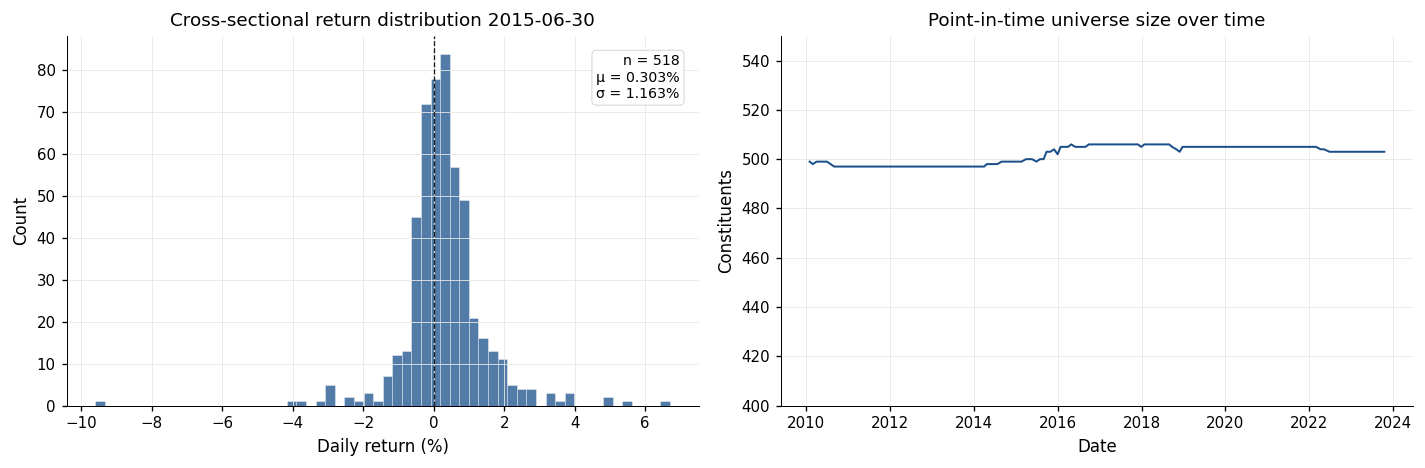

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: cross-sectional return distribution on a sample date
ax = axes[0]
sample_rets = returns.loc['2015-06-30'].dropna()
ax.hist(sample_rets * 100, bins=60, color=COLORS['scaled'], alpha=0.75, edgecolor='white', linewidth=0.3)
ax.axvline(0, color='#1a1a18', linewidth=0.8, linestyle='--')
ax.set_xlabel('Daily return (%)')
ax.set_ylabel('Count')
ax.set_title('Cross-sectional return distribution 2015-06-30')
ax.text(0.97, 0.95, f'n = {len(sample_rets)}\nμ = {sample_rets.mean()*100:.3f}%\nσ = {sample_rets.std()*100:.3f}%',
        transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc', linewidth=0.5))

# Right: universe size over time
ax = axes[1]
ax.plot([d.to_timestamp() if hasattr(d, 'to_timestamp') else d for d in rebalancing_dates],
        universe_sizes, color=COLORS['scaled'], linewidth=1.2)
ax.set_xlabel('Date')
ax.set_ylabel('Constituents')
ax.set_title('Point-in-time universe size over time')
ax.set_ylim(400, 550)

plt.tight_layout()
plt.savefig('results/fig_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 2. Signal construction

Four transformations are applied in sequence at each monthly rebalancing date.

### 2.1 12-1 month momentum return  *(Jegadeesh & Titman 1993)*

$$r_{\text{mom}}(i, T) = \prod_{t=T-252}^{T-21}(1 + r_t^i) - 1$$

The **one-month skip** (T−21 to T) avoids the short-term reversal documented by Jegadeesh (1990):
stocks that performed well in the most recent month tend to reverse, contaminating the signal.

### 2.2 Sharpe scaling  *(Asness, Moskowitz & Pedersen 2013)*

$$\tilde{r}_{\text{mom}}(i, T) = \frac{r_{\text{mom}}(i, T)}{\hat{\sigma}_i(63d)}$$

Dividing by realised volatility converts raw momentum into a risk-adjusted signal. A 30% return
in a 15%-vol stock contains more information than the same return in a 40%-vol stock.
Volatility is floored at 5% to prevent division by near-zero values.

### 2.3 Sector neutralisation  *(Asness et al. 2013 / Moskowitz & Grinblatt 1999)*

$$s(i, T) = \tilde{r}_{\text{mom}}(i, T) - \text{median}_{j \in \text{sector}(i)}\{\tilde{r}_{\text{mom}}(j, T)\}$$

Subtracting the within-GICS-sector **median** (robust to outliers vs mean) removes macro
co-movement. When oil prices rise, all energy stocks gain together that co-movement is not
stock-specific alpha. What remains is relative momentum within sectors.

### 2.4 Inverse-volatility position sizing

$$w_i = \pm \frac{1/\hat{\sigma}_i}{\sum_{j \in \text{leg}} 1/\hat{\sigma}_j}$$

Stocks in the top quintile form the long leg, bottom quintile the short leg. Within each leg,
positions are weighted by $1/\sigma_i$ and independently normalised so the long leg sums to +1
and the short leg to −1. This ensures **equal risk contribution** across positions: a 2% notional
weight in a 50%-vol stock contributes far more portfolio risk than the same weight in a 20%-vol stock.

> **Point-in-time correctness:** every computation uses `returns.loc[returns.index < as_of_date]`
> (strict less-than). No future information enters the signal at any step.


In [ ]:
from momentum_signal import (
    compute_momentum_return, compute_realized_volatility,
    sharpe_scale_signal, neutralize_sectors,
    compute_portfolio_weights, compute_all_signals,
    load_sector_map, analyze_signal_decay,
    SIGNALS_PATH,
)

sector_map = load_sector_map()

# Load or compute signals
if os.path.exists(SIGNALS_PATH):
    print('Loading precomputed signals...')
    weights = pd.read_parquet(SIGNALS_PATH)
else:
    print('Computing signals (this takes ~5-10 min)...')
    weights = compute_all_signals(returns, rebalancing_dates, sector_map)
    os.makedirs(os.path.dirname(SIGNALS_PATH), exist_ok=True)
    weights.to_parquet(SIGNALS_PATH)

# Portfolio construction statistics
n_long  = (weights > 0).sum(axis=1)
n_short = (weights < 0).sum(axis=1)
long_sum  = weights[weights > 0].sum(axis=1)
short_sum = weights[weights < 0].sum(axis=1)

print('=' * 55)
print('  Signal matrix')
print('=' * 55)
print(f'  Rebalancing dates    : {len(weights)}')
print(f'  Tickers in universe  : {weights.shape[1]}')
print(f'  Avg long positions   : {n_long.mean():.1f}')
print(f'  Avg short positions  : {n_short.mean():.1f}')
print(f'  Avg long sum         : {long_sum.mean():.4f}  (target: +1.0)')
print(f'  Avg short sum        : {short_sum.mean():.4f}  (target: -1.0)')
print()

# Sample weights at one rebalancing date
sample_date = weights.index[24]   # ~2 years in
sample_w    = weights.loc[sample_date]
print(f'  Sample weights  {sample_date.date()}')
print(f'  Top 5 longs  : {sample_w[sample_w > 0].nlargest(5).round(4).to_dict()}')
print(f'  Top 5 shorts : {sample_w[sample_w < 0].nsmallest(5).round(4).to_dict()}')
print('=' * 55)


Loading precomputed signals...
  Signal matrix
  Rebalancing dates    : 144
  Tickers in universe  : 515
  Avg long positions   : 77.7
  Avg short positions  : 78.0
  Avg long sum         : 1.0000  (target: +1.0)
  Avg short sum        : -1.0000  (target: -1.0)

  Sample weights — 2013-01-29
  Top 5 longs  : {'JNJ': 0.0333, 'SPG': 0.023, 'CL': 0.0218, 'NEE': 0.0218, 'DTE': 0.0211}
  Top 5 shorts : {'MCD': -0.0274, 'CAH': -0.0253, 'APD': -0.025, 'ED': -0.0247, 'BDX': -0.0231}


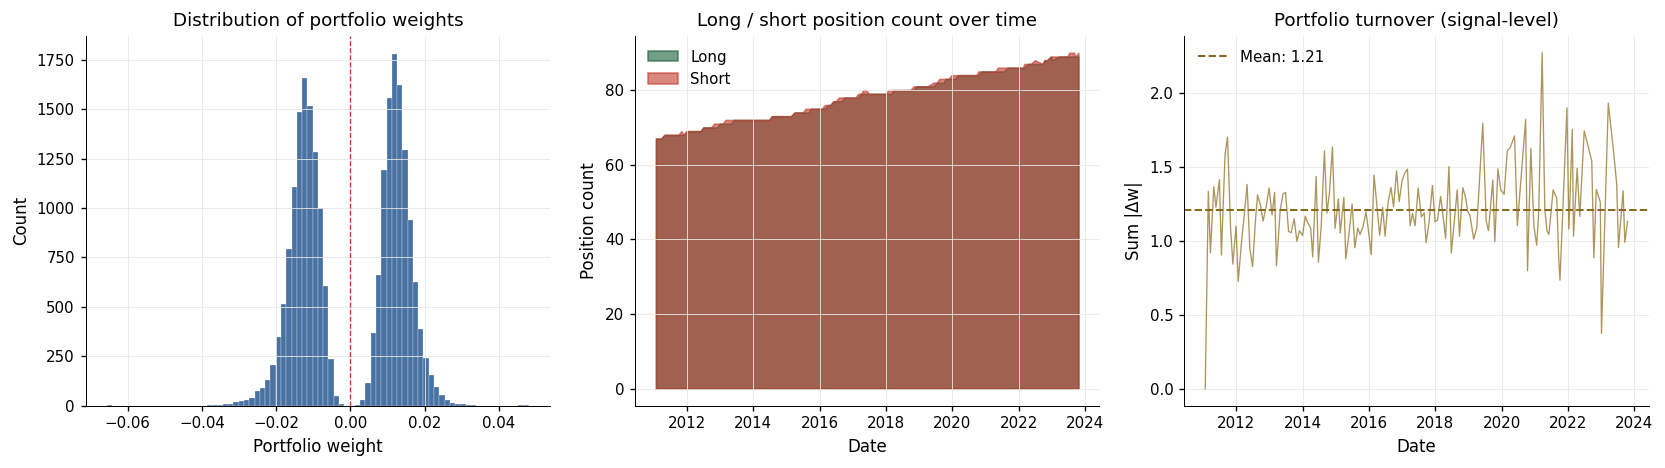

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Left: distribution of non-zero weights
ax = axes[0]
all_nonzero = weights.values.flatten()
all_nonzero = all_nonzero[all_nonzero != 0]
ax.hist(all_nonzero, bins=80, color=COLORS['scaled'], alpha=0.8, edgecolor='white', linewidth=0.2)
ax.axvline(0, color='#c0392b', linewidth=0.8, linestyle='--')
ax.set_xlabel('Portfolio weight')
ax.set_ylabel('Count')
ax.set_title('Distribution of portfolio weights')

# Middle: long/short position count over time
ax = axes[1]
ax.fill_between(weights.index, n_long,  alpha=0.6, color=COLORS['beta'],   label='Long')
ax.fill_between(weights.index, n_short, alpha=0.6, color=COLORS['static'], label='Short')
ax.set_xlabel('Date')
ax.set_ylabel('Position count')
ax.set_title('Long / short position count over time')
ax.legend()

# Right: turnover proxy weight changes between rebalancings
ax = axes[2]
turnover = weights.diff().abs().sum(axis=1).dropna()
ax.plot(turnover.index, turnover, color=COLORS['dynamic'], linewidth=0.8, alpha=0.7)
ax.axhline(turnover.mean(), color=COLORS['dynamic'], linewidth=1.2, linestyle='--',
           label=f'Mean: {turnover.mean():.2f}')
ax.set_xlabel('Date')
ax.set_ylabel('Sum |Δw|')
ax.set_title('Portfolio turnover (signal-level)')
ax.legend()

plt.tight_layout()
plt.savefig('results/fig_signal_overview.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.5 Information Coefficient decay

The **Information Coefficient (IC)** measures the predictive power of the signal: it is the
Spearman rank correlation between the signal at date T and the forward return over the next
L months. Spearman correlation is used in preference to Pearson because it is robust to
outliers and more appropriate for non-normal return distributions.

$$\text{IC}(L) = \rho_S\big(s(i, T),\; r_{\text{fwd}}(i, T, T+L)\big)$$

A signal that decays quickly (high IC at lag 1, near zero by lag 12) is a short-term signal
that benefits from frequent rebalancing. One that maintains IC at lag 12 is a long-term signal.
This analysis is standard practice in factor research it characterises the economic
mechanism of the signal independently of its backtest performance.

Interpretation benchmarks:
- IC > 0.05  meaningful predictive power  
- IC > 0.10  strong signal  
- |t-stat| > 2  statistically significant at 95% confidence


In [7]:
# Signal decay / IC analysis
# Note: this takes a few minutes as it recomputes the signal at each date
decay = analyze_signal_decay(returns, rebalancing_dates, lags=[1, 3, 6, 12])

# Display styled table
decay_display = decay.copy()
decay_display.columns = ['Lag (months)', 'IC mean', 'IC std', 'IC t-stat', 'N obs']
decay_display = decay_display.set_index('Lag (months)')

def colour_ic(val):
    if isinstance(val, float):
        if val > 0.05:  return 'color: #1a5c3a; font-weight: 500'
        if val > 0:     return 'color: #3a6a2a'
        if val < 0:     return 'color: #8a2a1a'
    return ''

styled = (decay_display.style
    .format({'IC mean': '{:+.4f}', 'IC std': '{:.4f}', 'IC t-stat': '{:+.2f}', 'N obs': '{:.0f}'})
    .applymap(colour_ic, subset=['IC mean', 'IC t-stat'])
    .set_caption('Information Coefficient by forward horizon')
    .set_table_styles([{'selector': 'caption', 'props': [('font-size', '12px'), ('font-weight', '500')]}])
)
display(styled)


,IC mean,IC std,IC t-stat,N obs
Lag (months),,,,
1,+0.0091,0.1958,+0.55,143
3,+0.0053,0.1852,+0.34,141
6,+0.0034,0.1815,+0.22,138
12,-0.0049,0.1469,-0.38,132


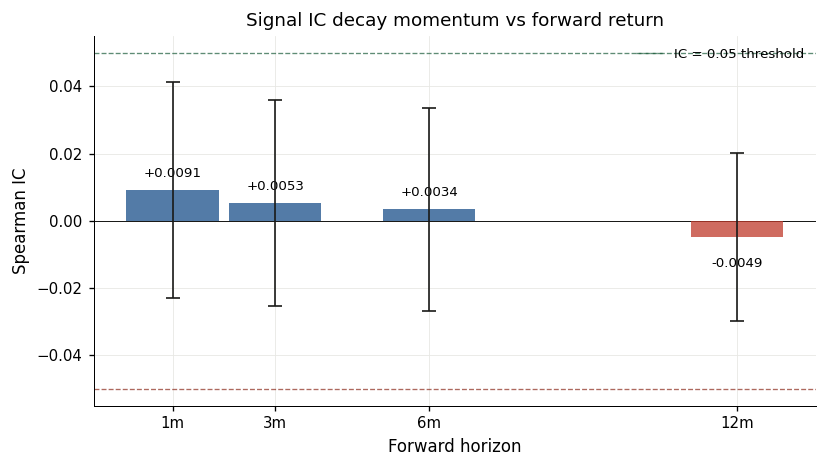

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))

lags    = decay['lag_months'].values
ic_mean = decay['IC_mean'].values
ic_std  = decay['IC_std'].values
n_obs   = decay['n_obs'].values
ic_se   = ic_std / np.sqrt(n_obs)

ax.bar(lags, ic_mean, color=[COLORS['scaled'] if v >= 0 else COLORS['static'] for v in ic_mean],
       width=1.8, alpha=0.75, zorder=3)
ax.errorbar(lags, ic_mean, yerr=1.96 * ic_se, fmt='none',
            color='#1a1a18', capsize=4, linewidth=1, zorder=4)
ax.axhline(0,    color='#1a1a18', linewidth=0.6)
ax.axhline(0.05, color='#1a5c3a', linewidth=0.8, linestyle='--', alpha=0.7, label='IC = 0.05 threshold')
ax.axhline(-0.05,color='#8a2a1a', linewidth=0.8, linestyle='--', alpha=0.7)

ax.set_xticks(lags)
ax.set_xticklabels([f'{l}m' for l in lags])
ax.set_xlabel('Forward horizon')
ax.set_ylabel('Spearman IC')
ax.set_title('Signal IC decay momentum vs forward return')
ax.legend(fontsize=8)

for i, (lag, ic, se) in enumerate(zip(lags, ic_mean, ic_se)):
    ax.text(lag, ic + (0.003 if ic >= 0 else -0.006), f'{ic:+.4f}',
            ha='center', va='bottom' if ic >= 0 else 'top', fontsize=8)

plt.tight_layout()
plt.savefig('results/fig_ic_decay.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 3. Backtest engine

The simulation runs as a **daily loop over 3,521 trading days**. No pre-built backtesting
library is used execution, costs, weight drift, and scaling are all implemented explicitly.

### 3.1 Execution model

- Signal computed at close of date T, executed at close of T+1 (T+1 open approximation)
- Between rebalancings, weights drift daily: $w_i(t+1) = w_i(t) \cdot (1 + r_i(t)) / (1 + r_p(t))$

### 3.2 Cost model

$$r_{\text{net}}(t) = r_{\text{gross}}(t) - \underbrace{\frac{1}{2}\sum_i |\Delta w_i| \cdot c_{\text{tc}}}_{\text{transaction cost}} - \underbrace{|W_{\text{short}}| \cdot \frac{c_{\text{borrow}}}{252}}_{\text{daily borrow accrual}}$$

Transaction costs (10bps one-way) are applied **only on actual turnover** unchanged positions
incur no cost. Borrow costs (200bps annual) accrue daily on total short exposure.

### 3.3 Volatility targeting  *(Daniel & Moskowitz 2016)*

At each rebalancing, the entire portfolio is scaled by:
$$k_t = \min\left(\frac{\sigma_{\text{target}}}{\hat{\sigma}_{\text{WML}}(126d)},\; 2.0\right)$$

When recent portfolio volatility exceeds the 10% target, gross exposure is reduced.
The signal (which stocks to hold) is unchanged only total capital deployed varies.

### 3.4 Dynamic weighting  *(Daniel & Moskowitz 2016, Eq. 6)*

Replaces the simple vol-scaling factor with the optimal Markowitz weight:

$$w^*_t = \frac{\hat{\mu}_{t-1}}{2\lambda \cdot \hat{\sigma}^2_{\text{WML},t-1}}$$

The conditional expected return $\hat{\mu}_{t-1}$ is forecasted via an **expanding-window OLS**
regression of past monthly WML returns on the interaction $I_B \cdot \sigma^2_m$, where $I_B$
is a bear market indicator (cumulative market return over prior 24 months < 0). The risk
aversion parameter $\lambda$ is calibrated from the historical distribution of past Markowitz
ratios to match the 10% vol target in expectation:

$$\lambda = \frac{\sqrt{\mathbb{E}[\text{raw\_scale}^2_t \cdot \hat{\sigma}^2_{\text{WML},t}]}}{2 \cdot \sigma_{\text{target}}}$$

All estimates use an expanding window strictly out-of-sample.

### 3.5 Beta-filtered short leg

Rolling 126-day betas are computed for each stock against the equal-weight benchmark.
Within the short quintile, only above-median-beta stocks are retained, then **independently
renormalised to -1** to preserve dollar-neutrality. High-beta recent losers amplify the WML
factor; low-beta losers contribute less alpha and are most prone to violent reversals during
recovery rallies.


In [10]:
from backtest import (
    simulate_portfolio, compute_benchmark,
    compute_metrics, compute_rolling_beta,
    walk_forward_validation, analyze_regimes,
    BASE_BORROW_COST,
)

os.makedirs('results', exist_ok=True)

benchmark = compute_benchmark(returns)
betas     = compute_rolling_beta(returns, benchmark)

print('Running strategy variants...')

# 1. Static WML
pf_static  = simulate_portfolio(weights, returns, use_vol_scaling=False)
m_static   = compute_metrics(pf_static['net_return'], benchmark, 'Static WML')
print('  [1/6] Static WML')

# 2. Constant vol scaling
pf_scaled  = simulate_portfolio(weights, returns, use_vol_scaling=True)
m_scaled   = compute_metrics(pf_scaled['net_return'], benchmark, 'Vol-Scaled WML')
print('  [2/6] Vol-Scaled WML')

# 3. Beta-filtered shorts + vol scaling
pf_beta    = simulate_portfolio(weights, returns, use_vol_scaling=True,
                                 borrow_cost_annual=BASE_BORROW_COST,
                                 beta_filter=True, betas=betas)
m_beta     = compute_metrics(pf_beta['net_return'], benchmark, 'Beta-Filtered Vol-Scaled')
print('  [3/6] Beta-Filtered Vol-Scaled')

# 4. Dynamic weighting (D&M 2016 Eq. 6)
pf_dynamic = simulate_portfolio(weights, returns, dynamic_weighting=True,
                                 benchmark_returns=market_returns)
m_dynamic  = compute_metrics(pf_dynamic['net_return'], benchmark, 'Dynamic Weighting (D&M 2016)')
print('  [4/6] Dynamic Weighting')

# 5. Dynamic + beta filter
pf_beta_dyn = simulate_portfolio(weights, returns, dynamic_weighting=True,
                                  benchmark_returns=market_returns,
                                  beta_filter=True, betas=betas)
m_beta_dyn  = compute_metrics(pf_beta_dyn['net_return'], benchmark, 'Beta-Filtered Dynamic')
print('  [5/6] Beta-Filtered Dynamic')

# 6. Long-only
pf_long    = simulate_portfolio(weights, returns, use_vol_scaling=True, long_only=True)
m_long     = compute_metrics(pf_long['net_return'], benchmark, 'Long-Only (top quintile)')
print('  [6/6] Long-Only')

# Benchmark
m_bench    = compute_metrics(benchmark, label='EW Benchmark')

print('\nAll variants complete.')

# Collect all metrics
all_metrics = [m_static, m_scaled, m_beta, m_dynamic, m_beta_dyn, m_long, m_bench]
metrics_df  = pd.DataFrame(all_metrics).set_index('label')
metrics_df.to_csv('results/metrics.csv')
print('Metrics saved → results/metrics.csv')


Running strategy variants...
  [1/6] Static WML
  [2/6] Vol-Scaled WML
  [3/6] Beta-Filtered Vol-Scaled
  [4/6] Dynamic Weighting
  [5/6] Beta-Filtered Dynamic
  [6/6] Long-Only

All variants complete.
Metrics saved → results/metrics.csv


---
## 4. Results

### 4.1 Strategy comparison table


In [15]:
display_cols = ['annual_return', 'annual_vol', 'sharpe', 'sortino',
                'max_drawdown', 'calmar', 'hit_rate', 'alpha', 'alpha_tstat', 'beta']

col_rename = {
    'annual_return' : 'Return',
    'annual_vol'    : 'Vol',
    'sharpe'        : 'Sharpe',
    'sortino'       : 'Sortino',
    'max_drawdown'  : 'Max DD',
    'calmar'        : 'Calmar',
    'hit_rate'      : 'Hit rate',
    'alpha'         : 'Alpha (ann.)',
    'alpha_tstat'   : 'α t-stat',
    'beta'          : 'Beta',
}

table = metrics_df[display_cols].rename(columns=col_rename)

def fmt_pct(v):  return f'{v:+.2%}' if pd.notna(v) else '-'
def fmt_2(v):    return f'{v:.2f}'  if pd.notna(v) else '-'
def fmt_2s(v):   return f'{v:+.2f}' if pd.notna(v) else '-'

def style_sharpe(v):
    if not isinstance(v, (int, float)) or pd.isna(v): return ''
    if v > 0.3:  return 'color: #1a5c3a; font-weight: 600'
    if v > 0:    return 'color: #3a6a2a'
    return 'color: #8a2a1a'

def style_return(v):
    if not isinstance(v, (int, float)) or pd.isna(v): return ''
    return 'color: #1a5c3a' if v > 0 else 'color: #8a2a1a'

styled_table = (
    table.style
    .format({
        'Return'    : fmt_pct,
        'Vol'       : fmt_pct,
        'Sharpe'    : fmt_2,
        'Sortino'   : fmt_2,
        'Max DD'    : fmt_pct,
        'Calmar'    : fmt_2,
        'Hit rate'  : '{:.1%}',
        'Alpha (ann.)': fmt_pct,
        'α t-stat'  : fmt_2s,
        'Beta'      : '{:.3f}',
    })
    .applymap(style_sharpe, subset=['Sharpe'])
    .applymap(style_return, subset=['Return'])
    .set_caption('Strategy performance summary net of 10bps transaction costs and 200bps borrow cost')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '12px'), ('font-weight', '500'), ('padding', '8px 0')]},
        {'selector': 'th', 'props': [('font-size', '11px'), ('text-align', 'right')]},
        {'selector': 'td', 'props': [('font-size', '11px'), ('text-align', 'right'), ('font-family', 'monospace')]},
    ])
    .highlight_between(subset=['Sharpe'], left=0.3, right=999,
                       props='background-color: #f0f8f2')
)

display(styled_table)

print('\nNote: Alpha t-statistics use OLS standard errors without Newey-West')
print('correction. Given autocorrelated momentum returns, true confidence')
print('intervals are wider than reported here.')


,Return,Vol,Sharpe,Sortino,Max DD,Calmar,Hit rate,Alpha (ann.),α t-stat,Beta
label,,,,,,,,,,
Static WML,-3.60%,+11.36%,-0.32,-0.37,-52.38%,-0.07,44.0%,-0.41%,-0.14,-0.149
Vol-Scaled WML,-2.28%,+10.28%,-0.22,-0.28,-42.73%,-0.05,44.0%,+0.25%,+0.09,-0.116
Beta-Filtered Vol-Scaled,+3.69%,+8.85%,0.42,0.51,-16.47%,0.22,53.6%,+0.65%,+0.30,0.193
Dynamic Weighting (D&M 2016),-0.32%,+10.64%,-0.03,-0.04,-30.27%,-0.01,44.6%,+0.36%,+0.13,-0.006
Beta-Filtered Dynamic,+3.29%,+9.03%,0.36,0.40,-17.83%,0.18,53.6%,+0.46%,+0.21,0.183
Long-Only (top quintile),+7.26%,+13.34%,0.54,0.62,-31.69%,0.23,57.7%,-2.28%,-1.15,0.583
EW Benchmark,+16.92%,+19.07%,0.89,1.10,-39.84%,0.42,68.5%,-,-,nan



Note: Alpha t-statistics use OLS standard errors without Newey-West
correction. Given autocorrelated momentum returns, true confidence
intervals are wider than reported here.


### 4.2 Cumulative net returns

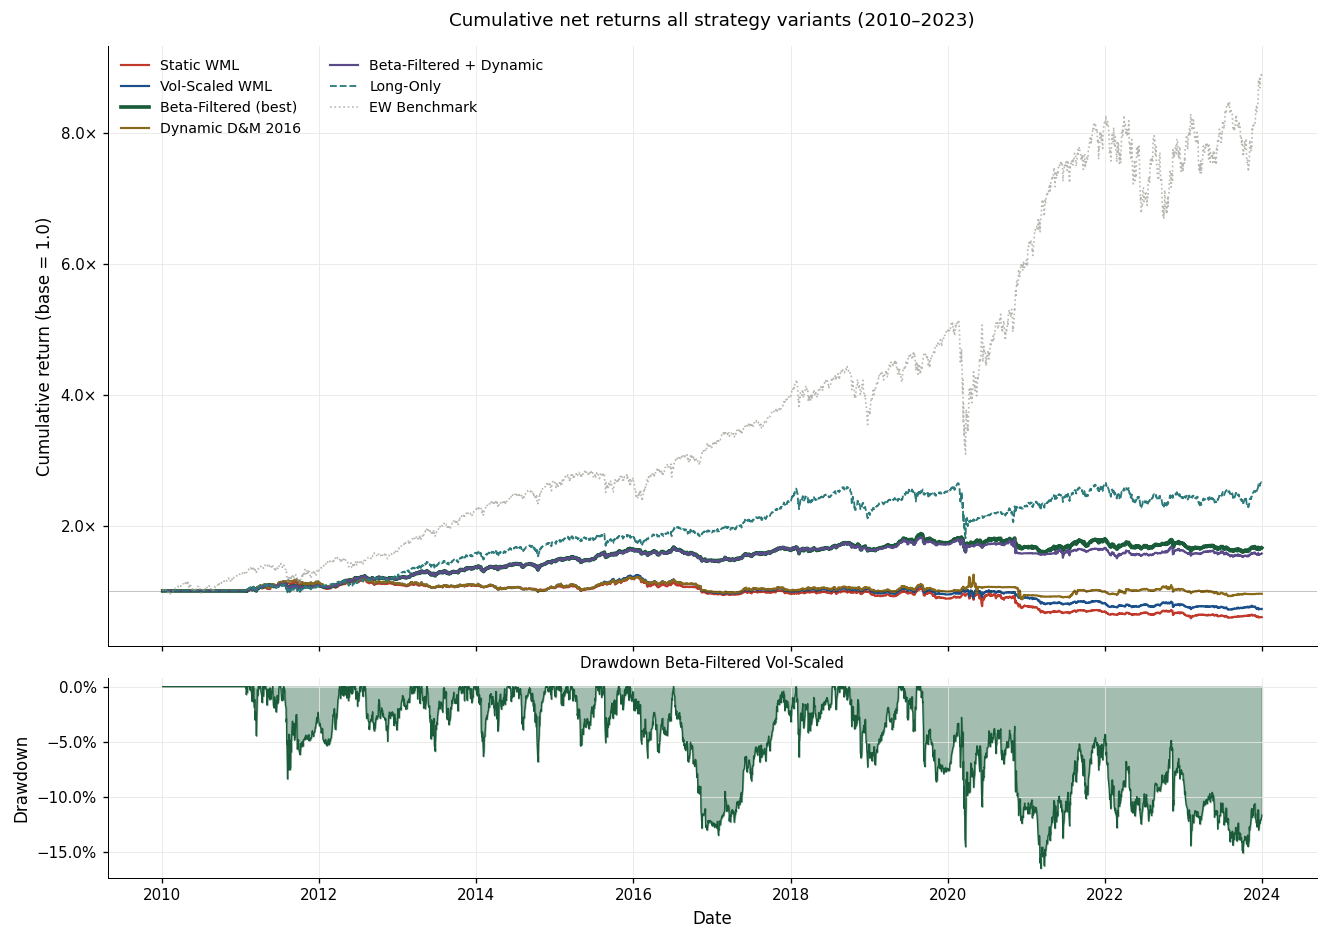

In [18]:
portfolios = [
    (pf_static,  m_static,  COLORS['static'],   'Static WML',              '-',  1.3),
    (pf_scaled,  m_scaled,  COLORS['scaled'],   'Vol-Scaled WML',          '-',  1.3),
    (pf_beta,    m_beta,    COLORS['beta'],     'Beta-Filtered (best)',    '-',  2.2),
    (pf_dynamic, m_dynamic, COLORS['dynamic'],  'Dynamic D&M 2016',        '-',  1.3),
    (pf_beta_dyn,m_beta_dyn,COLORS['beta_dyn'], 'Beta-Filtered + Dynamic', '-',  1.3),
    (pf_long,    m_long,    COLORS['long_only'],'Long-Only',               '--', 1.1),
]

fig, axes = plt.subplots(2, 1, figsize=(13, 9),
                          gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})

# ── Top: cumulative returns
ax = axes[0]
for pf, m, col, label, ls, lw in portfolios:
    cum = (1 + pf['net_return']).cumprod()
    ax.plot(cum.index, cum, color=col, linewidth=lw, linestyle=ls, label=label)

# Benchmark
bench_cum = (1 + benchmark).cumprod()
ax.plot(bench_cum.index, bench_cum, color=COLORS['benchmark'], linewidth=1,
        linestyle=':', label='EW Benchmark', alpha=0.7)

ax.axhline(1.0, color='#1a1a18', linewidth=0.5, linestyle='-', alpha=0.3)
ax.set_ylabel('Cumulative return (base = 1.0)')
ax.set_title('Cumulative net returns all strategy variants (2010–2023)', pad=12)
ax.legend(loc='upper left', fontsize=8.5, ncol=2)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.1f}×'))
ax.set_xticklabels([])

# ── Bottom: drawdown of best variant
ax = axes[1]
cum_beta = (1 + pf_beta['net_return']).cumprod()
dd_beta  = (cum_beta - cum_beta.cummax()) / cum_beta.cummax()
ax.fill_between(dd_beta.index, dd_beta, 0, color=COLORS['beta'], alpha=0.4)
ax.plot(dd_beta.index, dd_beta, color=COLORS['beta'], linewidth=0.8)
ax.set_ylabel('Drawdown')
ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Drawdown Beta-Filtered Vol-Scaled', fontsize=9, pad=6)

plt.savefig('results/fig_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.3 Long / short leg decomposition

Separating the long and short leg returns reveals where performance is generated and where
it is lost. This decomposition is essential for understanding whether the signal has genuine
predictive power or whether apparent performance is driven by structural factors.


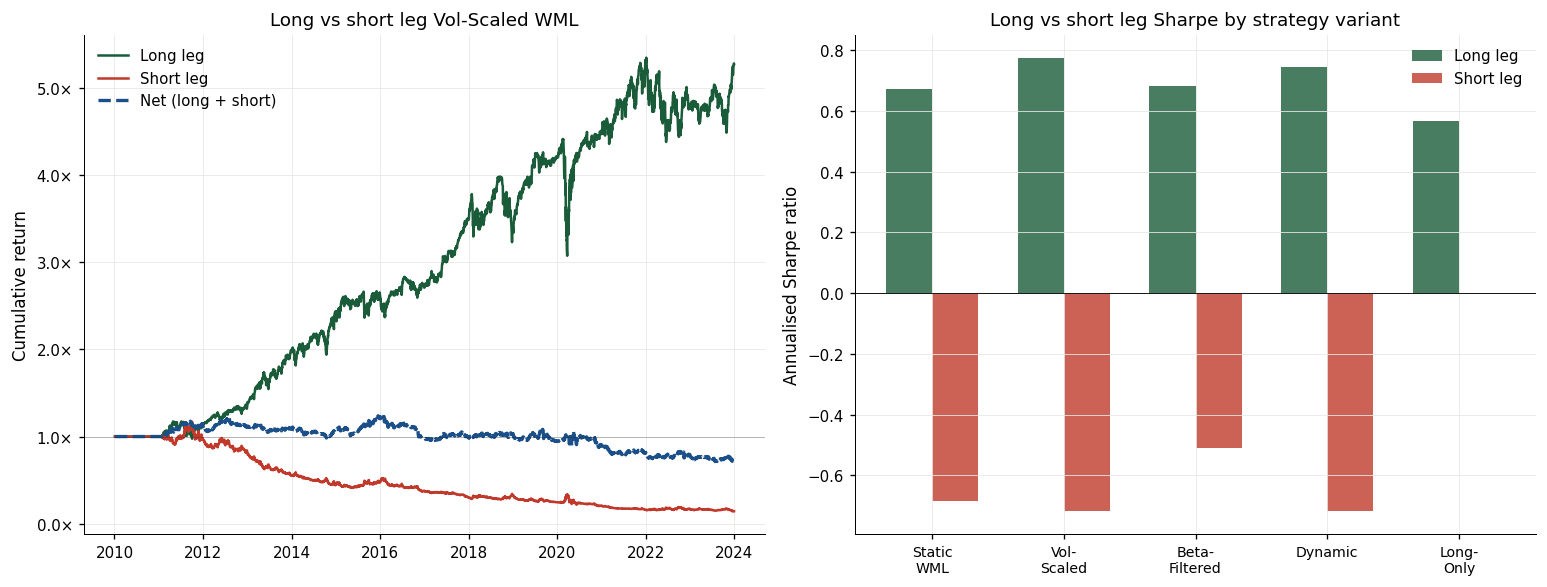

  Vol-Scaled long Sharpe: +0.78 | short Sharpe: -0.72
  Long-only long Sharpe: +0.57

  The long leg carries genuine signal. The short leg is the primary source of losses.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: cumulative long vs short leg for vol-scaled
ax = axes[0]
cum_long  = (1 + pf_scaled['long_return']).cumprod()
cum_short = (1 + pf_scaled['short_return']).cumprod()
cum_net   = (1 + pf_scaled['net_return']).cumprod()

ax.plot(cum_long.index,  cum_long,  color=COLORS['beta'],   linewidth=1.5, label='Long leg')
ax.plot(cum_short.index, cum_short, color=COLORS['static'], linewidth=1.5, label='Short leg')
ax.plot(cum_net.index,   cum_net,   color=COLORS['scaled'], linewidth=2.0, label='Net (long + short)', linestyle='--')
ax.axhline(1.0, color='#1a1a18', linewidth=0.5, alpha=0.3)
ax.set_ylabel('Cumulative return')
ax.set_title('Long vs short leg Vol-Scaled WML')
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.1f}×'))

# ── Right: annual long vs short leg Sharpe comparison
ax = axes[1]
leg_labels = ['Static\nWML', 'Vol-\nScaled', 'Beta-\nFiltered', 'Dynamic', 'Long-\nOnly']

def leg_sharpe(pf, col):
    r = pf[col].dropna()
    n = len(r) / 252
    ann_ret = (1 + r).prod() ** (1/n) - 1
    ann_vol = r.std() * np.sqrt(252)
    return ann_ret / ann_vol if ann_vol > 0 else 0

long_sharpes  = [leg_sharpe(p, 'long_return')  for p in [pf_static, pf_scaled, pf_beta, pf_dynamic, pf_long]]
short_sharpes = [leg_sharpe(p, 'short_return') for p in [pf_static, pf_scaled, pf_beta, pf_dynamic, pf_long]]

x   = np.arange(len(leg_labels))
w   = 0.35
ax.bar(x - w/2, long_sharpes,  w, color=COLORS['beta'],   alpha=0.8, label='Long leg')
ax.bar(x + w/2, short_sharpes, w, color=COLORS['static'], alpha=0.8, label='Short leg')
ax.axhline(0, color='#1a1a18', linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(leg_labels, fontsize=8.5)
ax.set_ylabel('Annualised Sharpe ratio')
ax.set_title('Long vs short leg Sharpe by strategy variant')
ax.legend()

plt.tight_layout()
plt.savefig('results/fig_leg_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print leg Sharpe summary
print(f'  Vol-Scaled long Sharpe: {long_sharpes[1]:+.2f} | short Sharpe: {short_sharpes[1]:+.2f}')
print(f'  Long-only long Sharpe: {long_sharpes[4]:+.2f}')
print()
print('  The long leg carries genuine signal. The short leg is the primary source of losses.')


---
## 5. Walk-forward validation

The 14-year period is split into **5 sequential, non-overlapping folds** of approximately
2.8 years each. No data from fold $n$ is visible when computing fold $n-1$.
A strategy that concentrates all its returns in a single period is less convincing than
one that earns consistently across different market regimes.

This is a strictly out-of-sample test of strategy stability not an optimisation.


In [21]:
wf_results = walk_forward_validation(weights, returns, benchmark)

# ── Display
wf_display = wf_results[['label', 'annual_return', 'sharpe', 'max_drawdown', 'hit_rate']].copy()
wf_display.columns = ['Period', 'Return', 'Sharpe', 'Max DD', 'Hit rate']
wf_display = wf_display.set_index('Period')

styled_wf = (
    wf_display.style
    .format({'Return': '{:+.2%}', 'Sharpe': '{:+.2f}', 'Max DD': '{:.2%}', 'Hit rate': '{:.1%}'})
    .applymap(style_sharpe, subset=['Sharpe'])
    .applymap(style_return, subset=['Return'])
    .set_caption('Walk-forward validation vol-scaled long-short, 5 sequential folds')
    .set_table_styles([{'selector': 'caption', 'props': [('font-size', '12px'), ('font-weight', '500')]}])
)
display(styled_wf)


,Return,Sharpe,Max DD,Hit rate
Period,,,,
Fold 1 (2010-01 → 2012-10),+4.42%,+0.56,-10.08%,38.2%
Fold 2 (2012-10 → 2015-08),-0.30%,-0.04,-14.50%,51.4%
Fold 3 (2015-08 → 2018-05),-2.85%,-0.30,-23.27%,47.1%
Fold 4 (2018-05 → 2021-03),-7.80%,-0.55,-26.69%,28.6%
Fold 5 (2021-03 → 2023-12),-4.45%,-0.41,-15.82%,50.0%


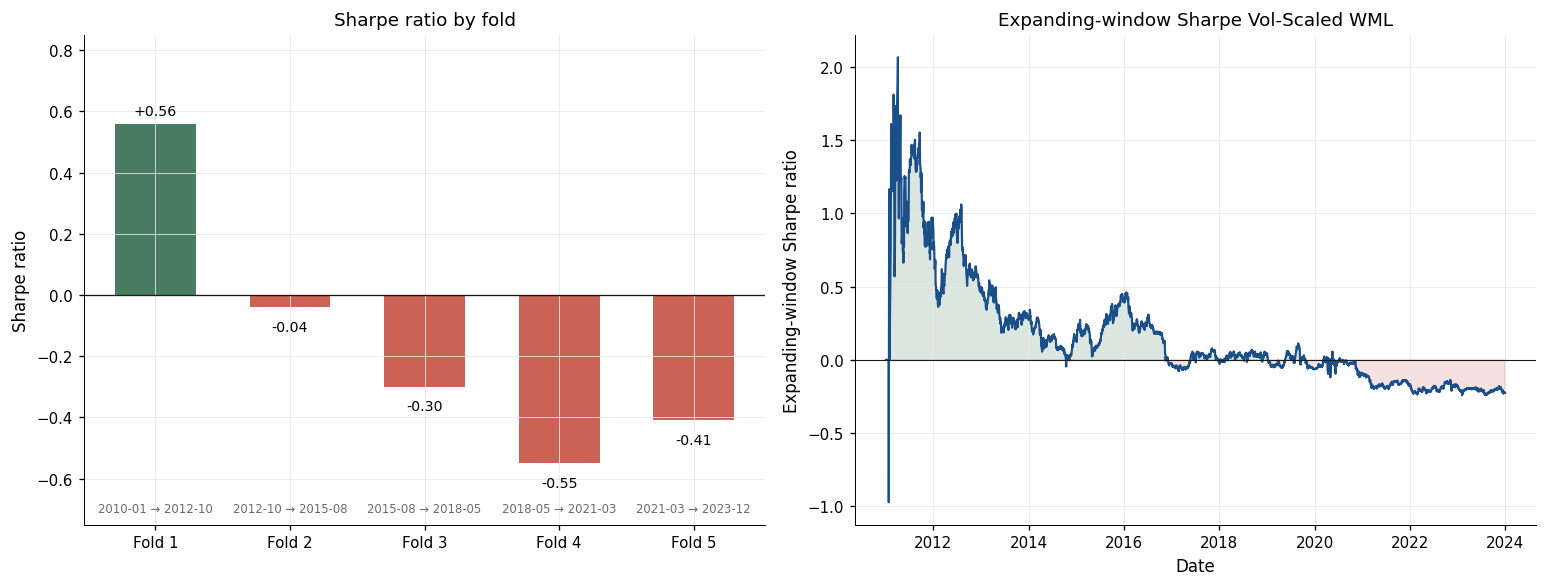

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fold_sharpes = wf_results['sharpe'].values
fold_returns = wf_results['annual_return'].values
fold_labels  = [f'Fold {i+1}' for i in range(len(fold_sharpes))]
fold_periods = wf_results['label'].str.extract(r'\((.+)\)')[0].values

# Left: Sharpe by fold
ax = axes[0]
bar_colors = [COLORS['beta'] if s > 0 else COLORS['static'] for s in fold_sharpes]
bars = ax.bar(range(len(fold_sharpes)), fold_sharpes, color=bar_colors, alpha=0.8, width=0.6)
ax.axhline(0, color='#1a1a18', linewidth=0.8)
for i, (s, p) in enumerate(zip(fold_sharpes, fold_periods)):
    ax.text(i, s + (0.02 if s >= 0 else -0.04), f'{s:+.2f}',
            ha='center', va='bottom' if s >= 0 else 'top', fontsize=8.5, fontweight='500')
    ax.text(i, -0.72, p, ha='center', va='bottom', fontsize=7, color='#6b6b64', rotation=0)
ax.set_xticks(range(len(fold_labels)))
ax.set_xticklabels(fold_labels)
ax.set_ylabel('Sharpe ratio')
ax.set_title('Sharpe ratio by fold')
ax.set_ylim(-0.75, 0.85)

# Right: running Sharpe (expanding window)
ax = axes[1]
net = pf_scaled['net_return']
min_periods = 252
expanding_sharpe = []
dates_sharpe = []
for i in range(min_periods, len(net)):
    r   = net.iloc[:i]
    n_y = len(r) / 252
    ar  = (1 + r).prod() ** (1/n_y) - 1
    av  = r.std() * np.sqrt(252)
    expanding_sharpe.append(ar / av if av > 0 else 0)
    dates_sharpe.append(net.index[i])

ax.plot(dates_sharpe, expanding_sharpe, color=COLORS['scaled'], linewidth=1.3)
ax.axhline(0, color='#1a1a18', linewidth=0.8, linestyle='-', alpha=0.3)
ax.axhline(0, color='#1a1a18', linewidth=0.6)
ax.fill_between(dates_sharpe, expanding_sharpe, 0,
                where=[s >= 0 for s in expanding_sharpe],
                color=COLORS['beta'], alpha=0.15)
ax.fill_between(dates_sharpe, expanding_sharpe, 0,
                where=[s < 0 for s in expanding_sharpe],
                color=COLORS['static'], alpha=0.15)
ax.set_ylabel('Expanding-window Sharpe ratio')
ax.set_xlabel('Date')
ax.set_title('Expanding-window Sharpe Vol-Scaled WML')

plt.tight_layout()
plt.savefig('results/fig_walk_forward.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6. Regime analysis

Performance is decomposed across three structural market regimes to test whether the
strategy's difficulties are concentrated in one specific environment or are broad-based.

The COVID period (2020-2021) is of particular interest: it is precisely the scenario
described in Daniel & Moskowitz (2016) a bear market followed by a violent recovery rally
where momentum shorts (recent losers, cyclicals) rebound sharply while momentum longs
(recent winners, overvalued growth) fall hardest.


In [24]:
regime_results = analyze_regimes(pf_scaled, benchmark)

reg_display = regime_results[['regime', 'annual_return', 'annual_vol', 'sharpe',
                               'max_drawdown', 'hit_rate', 'alpha']].copy()
reg_display.columns = ['Regime', 'Return', 'Vol', 'Sharpe', 'Max DD', 'Hit rate', 'Alpha']
reg_display = reg_display.set_index('Regime')

styled_reg = (
    reg_display.style
    .format({'Return': '{:+.2%}', 'Vol': '{:.2%}', 'Sharpe': '{:+.2f}',
             'Max DD': '{:.2%}', 'Hit rate': '{:.1%}', 'Alpha': '{:+.2%}'})
    .applymap(style_sharpe, subset=['Sharpe'])
    .applymap(style_return, subset=['Return', 'Alpha'])
    .set_caption('Regime decomposition Vol-Scaled WML')
    .set_table_styles([{'selector': 'caption', 'props': [('font-size', '12px'), ('font-weight', '500')]}])
)
display(styled_reg)


,Return,Vol,Sharpe,Max DD,Hit rate,Alpha
Regime,,,,,,
Bull market,-0.56%,8.79%,-0.06,-24.21%,44.2%,+0.79%
COVID crash/recovery,-7.13%,14.87%,-0.48,-25.22%,41.7%,-2.33%
Rate hike period,-5.77%,11.50%,-0.50,-14.80%,45.8%,-3.62%


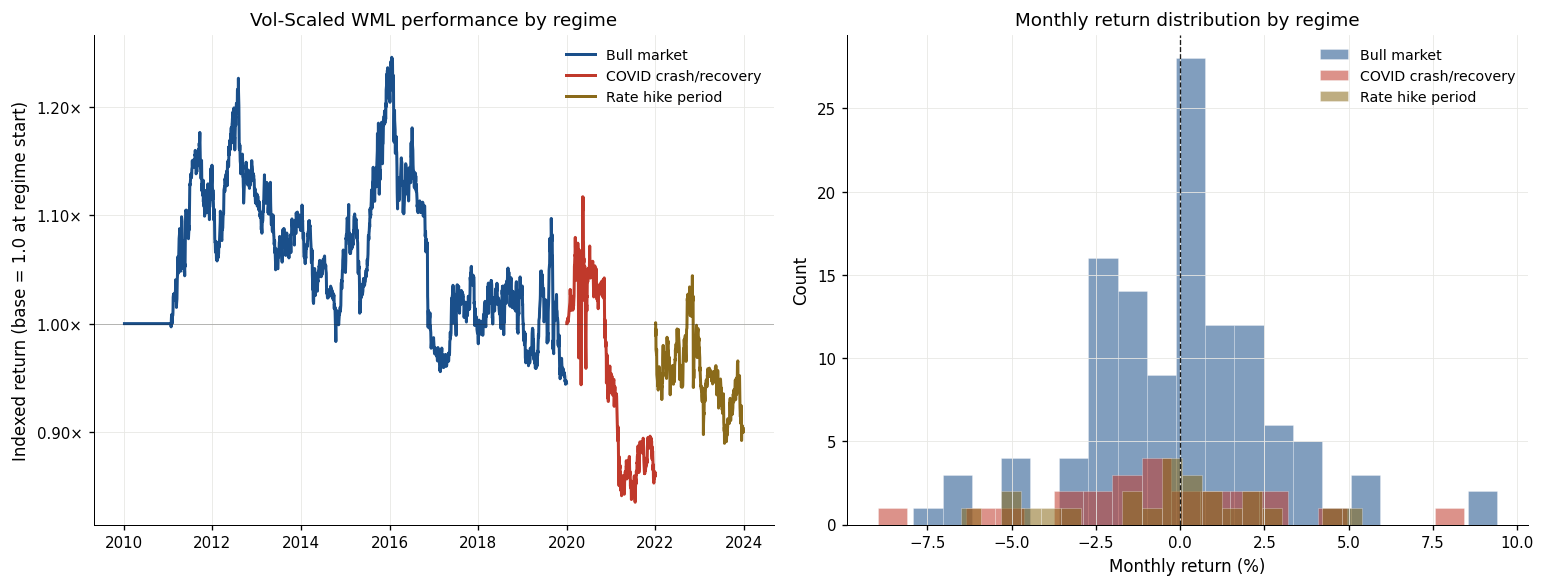

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

regimes = [
    ('Bull market',          '2010-01-01', '2019-12-31', COLORS['scaled']),
    ('COVID crash/recovery', '2020-01-01', '2021-12-31', COLORS['static']),
    ('Rate hike period',     '2022-01-01', '2023-12-31', COLORS['dynamic']),
]

# Left: cumulative return by regime (reset to 1 at start of each)
ax = axes[0]
net = pf_scaled['net_return']
for name, start, end, col in regimes:
    seg = net.loc[start:end]
    cum = (1 + seg).cumprod()
    cum = cum / cum.iloc[0]    # reset to 1
    ax.plot(cum.index, cum, color=col, linewidth=1.8, label=name)

ax.axhline(1.0, color='#1a1a18', linewidth=0.5, alpha=0.3)
ax.set_ylabel('Indexed return (base = 1.0 at regime start)')
ax.set_title('Vol-Scaled WML performance by regime')
ax.legend(fontsize=8.5)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.2f}×'))

# Right: monthly return distribution by regime
ax = axes[1]
for name, start, end, col in regimes:
    monthly = net.loc[start:end].resample('ME').apply(lambda x: (1+x).prod()-1)
    ax.hist(monthly * 100, bins=20, color=col, alpha=0.55, label=name, edgecolor='white', linewidth=0.3)

ax.axvline(0, color='#1a1a18', linewidth=0.8, linestyle='--')
ax.set_xlabel('Monthly return (%)')
ax.set_ylabel('Count')
ax.set_title('Monthly return distribution by regime')
ax.legend(fontsize=8.5)

plt.tight_layout()
plt.savefig('results/fig_regime_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7. Borrow cost sensitivity

The vol-scaled strategy is stress-tested across borrow cost scenarios from 0% to 5% annual.
This tests whether underperformance is driven by financing costs or by signal quality.


In [26]:
borrow_costs = [0.0, 0.01, 0.02, 0.03, 0.05]
borrow_results = []

for bc in borrow_costs:
    pf_bc = simulate_portfolio(weights, returns, use_vol_scaling=True, borrow_cost_annual=bc)
    m_bc  = compute_metrics(pf_bc['net_return'], benchmark, label=f'Borrow {bc:.1%}')
    borrow_results.append({
        'Borrow cost (p.a.)' : f'{bc:.1%}',
        'Annual return'      : m_bc['annual_return'],
        'Sharpe'             : m_bc['sharpe'],
        'Sortino'            : m_bc['sortino'],
        'Max drawdown'       : m_bc['max_drawdown'],
    })

borrow_df = pd.DataFrame(borrow_results).set_index('Borrow cost (p.a.)')

styled_borrow = (
    borrow_df.style
    .format({'Annual return': '{:+.2%}', 'Sharpe': '{:.2f}',
             'Sortino': '{:.2f}', 'Max drawdown': '{:.2%}'})
    .applymap(style_sharpe, subset=['Sharpe'])
    .applymap(style_return, subset=['Annual return'])
    .set_caption('Borrow cost sensitivity Vol-Scaled WML')
    .set_table_styles([{'selector': 'caption', 'props': [('font-size', '12px'), ('font-weight', '500')]}])
)
display(styled_borrow)

sharpes = [r['Sharpe'] for r in borrow_results]
bcs     = [bc for bc in borrow_costs]
slope   = np.polyfit(bcs, sharpes, 1)[0]
print(f'\n  Sharpe sensitivity: {slope:.1f} per unit borrow cost')
print(f'  i.e. ~{slope/100:.2f} Sharpe per 1% additional annual borrow cost')
print(f'  At 0% borrow cost: Sharpe = {sharpes[0]:.2f} signal quality, not financing, drives underperformance')


,Annual return,Sharpe,Sortino,Max drawdown
Borrow cost (p.a.),,,,
0.0%,-0.31%,-0.03,-0.04,-33.62%
1.0%,-1.30%,-0.13,-0.16,-38.34%
2.0%,-2.28%,-0.22,-0.28,-42.73%
3.0%,-3.25%,-0.32,-0.40,-48.35%
5.0%,-5.17%,-0.50,-0.64,-59.53%



  Sharpe sensitivity: -9.4 per unit borrow cost
  i.e. ~-0.09 Sharpe per 1% additional annual borrow cost
  At 0% borrow cost: Sharpe = -0.03 signal quality, not financing, drives underperformance


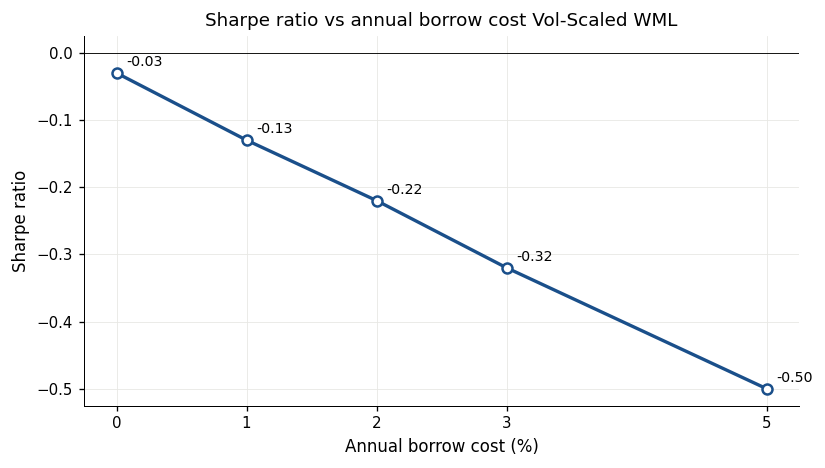

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot([bc*100 for bc in borrow_costs], sharpes,
        color=COLORS['scaled'], linewidth=2, marker='o', markersize=6, markerfacecolor='white',
        markeredgewidth=1.5)

for bc, sh in zip(borrow_costs, sharpes):
    ax.annotate(f'{sh:.2f}', (bc*100, sh), textcoords='offset points',
                xytext=(6, 4), fontsize=8.5)

ax.axhline(0, color='#1a1a18', linewidth=0.6)
ax.set_xlabel('Annual borrow cost (%)')
ax.set_ylabel('Sharpe ratio')
ax.set_title('Sharpe ratio vs annual borrow cost Vol-Scaled WML')
ax.set_xticks([bc*100 for bc in borrow_costs])

plt.tight_layout()
plt.savefig('results/fig_borrow_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Interpretation & Limitations

### 8.1 Key Findings

**1. The short leg drives almost all underperformance.**  
The long-only top-quintile strategy (Sharpe +0.54) substantially outperforms the full long-short
(-0.22). The short quintile is the primary source of losses, consistent with the literature: the
short side of momentum is more crash-prone, harder to hold through violent reversals, and carries
meaningful execution frictions. This asymmetry suggests the strategy's practical value lies almost
entirely in its long book.

**2. Beta filtering is the most effective single intervention.**  
Restricting shorts to above-median-beta stocks within the short quintile improves the Sharpe from
−0.22 to +0.42 and reduces maximum drawdown from −42.73% to −16.47%. High-beta recent losers
amplify the WML factor as intended, low-beta recent losers are prone to sharp mean-reversions
during recovery rallies and contribute negative alpha per unit of risk. This replicates the
Daniel & Moskowitz (2016) mechanism on a constrained large-cap universe.

**3. Dynamic weighting requires a positive unconditional expected return to add value.**  
The D&M (2016) OLS scaling model is fit on raw WML returns, which are predominantly negative over
2010–2023. The regression learns to expect losses, and the resulting λ reduces exposure
directionally correct, but insufficient to generate positive returns. D&M (2016) demonstrated
the mechanism on 1927–2012 data where the unconditional momentum premium was strongly positive.
The 2010–2023 sample is structurally different, calibrating λ on the beta-filtered portfolio
history is the logical next step but remains untested here.

**4. The momentum premium has weakened monotonically post-2012 on large-cap U.S. equities.**  
Four of five walk-forward folds are negative, with monotonically declining Sharpe ratios across
the evaluation window. This is consistent with McLean & Pontiff (2016): academic publication
attracts arbitrage capital that gradually erodes the premium. The 2010–2023 window likely
represents the post-publication decay period for the S&P 500 universe, where institutional
crowding is most acute.

---

### 8.2 Limitations

| # | Limitation | Severity | Directional impact | Natural fix |
|---|-----------|----------|--------------------|-------------|
| 1 | **Universe coverage gap (~25%)**  Yahoo Finance missing or incomplete return history drops ~75 of ~300 eligible historical constituents per period | Medium | Likely excludes distressed and thinly-traded names  the most fertile short candidates, mild short-leg alpha overstatement | Compustat / Norgate for clean point-in-time price history |
| 2 | **Shallow universe → high turnover (~70% monthly)**  with ~200–250 usable stocks, quintile portfolios hold only ~40–50 names, small rank shifts and sector-neutral re-ranking drive large churn even when the signal is stable | Medium | Cost drag of ~168 bps/year (70% × 2 sides × 10 bps × 12) already embedded in reported net returns, residual risk is that 10 bps understates impact for names near quintile boundaries | Expand to Russell 1000/3000, apply a turnover buffer or portfolio-level optimizer |
| 3 | **Flat borrowing cost assumption**  short-side financing costs applied as a uniform rate across all names and periods, sensitivity to the rate level tested via scenario analysis but cross-sectional dispersion not captured | Low–Medium | Understates drag on the most expensive-to-borrow shorts (distressed, high-short-interest names can cost 200–500 bps+), net short-leg alpha modestly overstated for those names | Stock-level borrow cost data (e.g. IHS Markit securities finance) |
| 4 | **Transaction cost model simplified (flat 10 bps)**  market impact not modeled, execution assumed at closing price | Low–Medium | Likely conservative for liquid large-caps, potentially aggressive for smaller-cap constituents near quintile edges, no intraday slippage captured | VWAP or Almgren-Chriss impact model scaled by ADV participation rate |
| 5 | **Risk-free rate assumed zero** Sharpe ratios computed as `mean(r_p) / std(r_p)` without subtracting the contemporaneous risk-free rate | Low pre-2022, Medium post-2022 | Negligible bias 2010–2021 when T-bills yielded near zero, Sharpe numerator overstated by ~5% annualized in 2022–2023 when Fed Funds exceeded 5%, materially inflating reported ratios for that sub-period | Subtract daily T-bill return from portfolio returns before computing Sharpe |
| 6 | **Short-term reversal not fully purged** 12-1 formation skips month t−1 but residual mean-reversion at the 2–3 month lag may partially contaminate the signal | Low–Medium | Modest downward bias on short-leg returns, effect dampened at monthly rebalance frequency but not eliminated | Extend skip to 12-3 (formation window t−12 to t−3) and compare Sharpe and turnover |
| 7 | **Sector classification not point-in-time** GICS sector map reflects current classifications, firms reclassified before 2018 carry anachronistic sector labels | Low | Minor neutralization inaccuracy concentrated pre-2018, unlikely to alter conclusions materially | Point-in-time GICS database from a data vendor |
| 8 | **No Fama-French factor attribution** portfolio returns not decomposed against systematic risk factors | Medium | Reported long-only Sharpe (+0.54) may partially reflect inadvertent exposure to quality, low-volatility, or size factors rather than pure momentum, true momentum alpha unknown | Regress monthly excess returns on FF5 + UMD factors, report alpha (intercept) and factor loadings |
| 9 | **Dynamic λ calibrated on raw WML, not beta-filtered series** the D&M scaling model is trained on the unfiltered momentum return history | Medium | λ learns the statistical properties of a predominantly negative return series, when overlaid on the beta-filtered portfolio it operates on a mismatched signal, likely under-scaling during favorable regimes | Re-run D&M calibration using the beta-filtered WML return history as the training series |
| 10 | **Equal-weight benchmark for alpha computation** alpha measured against an equal-weight average of universe constituents | Low | Equal-weight has a structural small-cap tilt that outperformed in parts of the sample window, artificially compressing measured long-side alpha | Use S&P 500 total return index (^GSPC) as the cap-weighted benchmark |
| 11 | **OLS standard errors without Newey-West correction** momentum returns exhibit positive serial autocorrelation | Low | Standard errors understated, t-statistics on alpha inflated, significance of individual fold results overstated | Apply Newey-West HAC standard errors with lag = 6–12 months |

---

### 8.3 On the ~70% Monthly Turnover

The elevated turnover is structural and stems from three compounding sources rather than
implementation error.

**Shallow universe.** After applying the 80% coverage filter to historical S&P 500 constituents,
the usable universe contracts to ~200–250 stocks per period. Quintile portfolios therefore contain
only 40–50 names. A rank change of just a few positions pushes a stock across a quintile boundary
and forces a trade that would be invisible in a 1,500-stock universe where the same shift is
absorbed within the quintile.

**Sector-neutral re-ranking.** Quintile assignment depends on a stock's momentum rank *relative
to its sector peers*, not in absolute terms. Month-to-month dispersion in sector-level returns
reshuffles relative ranks even when a stock's own momentum signal is unchanged, generating
turnover that is an artefact of the neutralization procedure rather than genuine signal change.

**Short holding period.** The 12-1 signal with a 1-month holding period and monthly rebalance
provides no mechanism to dampen marginal position changes. Stocks that barely qualify for a
quintile in month t are replaced in month t+1 regardless of how marginal their exclusion is.

At 10 bps applied to all trades, the embedded cost drag is approximately
**70% × 2 sides × 10 bps × 12 months ≈ 168 bps/year**, which is already reflected in all
reported net return figures. The residual concern is estimation error on that cost for the
least liquid names near quintile boundaries, not unmodeled drag.

---

### 8.4 References

- Jegadeesh, N. & Titman, S. (1993). Returns to buying winners and selling losers. *J. Finance*, 48(1).
- Asness, C., Moskowitz, T. & Pedersen, L. (2013). Value and momentum everywhere. *J. Finance*, 68(3).
- Daniel, K. & Moskowitz, T. (2016). Momentum crashes. *J. Financial Economics*, 122(2), 221–247.
- Moskowitz, T. & Grinblatt, M. (1999). Do industries explain momentum? *J. Finance*, 54(4).
- McLean, R.D. & Pontiff, J. (2016). Does academic research destroy return predictability? *J. Finance*, 71(1).
- López de Prado, M. (2018). *Advances in Financial Machine Learning*. Wiley.
- Grinold, R. & Kahn, R. (1999). *Active Portfolio Management* (2nd ed.). McGraw-Hill.